# Regulatory Effects

This is to demonstrate the three layer feedback loop for galactose Switch in *S. Cerevisiae*. The code is initially demonstrated for EAB poster session in 2024.

In [1]:
%run env.ipynb
import pickle
import os
import numpy as np
from jLM.RDME import File as RDMEFile
import jLM
import json
import matplotlib.pyplot as plt
import seaborn as sns
from traj_analysis_rdme import *
from tqdm import tqdm

first to acquire the data 

In [2]:
traj_dir = "/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20241021fixedgene_traj3traj4/"
# traj_dir = "/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20241107wtmt_ramsey/"
fig_dir = traj_dir + 'regulatory_effect/'
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
traj3 = [f for f in os.listdir(traj_dir) if f.startswith('yeast1.12') and '60'.lower() in f.lower() and f.endswith('.lm')]
# traj4 = [f for f in os.listdir(traj_dir) if f.startswith('yeast1.1') and 'traj4'.lower() in f.lower() and f.endswith('.lm')]
traj_suff = "_ode.jsonl"
region_suff = '_region.jsonl'
species_to_plot_1 = ['GAI', 'GAE']
species_to_plot_2 = ['G3', 'G3i','G80d', 'G80d_G3i', 'G4d']
species_to_plot_by_region = ['G2', 'G80d']
species_to_extract = species_to_plot_1 + species_to_plot_2 
species_to_extract.remove('GAE')
all_trajectories = {species: [] for species in species_to_extract}
all_region_trajectories = {species: [] for species in species_to_plot_by_region}
time_points = {'rdmeTs': None, 'odeTs':None, 'regionTs': None}

for traj_file in tqdm(traj3, desc="Processing files", unit="file"):
    traj, odeTraj, region_traj = get_traj(traj_dir, traj_file, traj_suff, region_suff=region_suff)
    rdmeTs, rdmeYs, odeTs, odeYs, regionTs, regionYs = get_data_for_plot(traj, odeTraj, region_traj=region_traj, sparse_factor = 1)
    # print(regionYs.keys())
    # here we first have to extract the time data 
    if time_points['rdmeTs'] is None: 
        time_points['rdmeTs'] = rdmeTs
        time_points['odeTs'] = odeTs
        time_points['regionTs'] = regionTs
    # extract the data 
    for species in species_to_extract:
        if species in rdmeYs.keys():
            all_trajectories[species].append(rdmeYs[species])
        else: 
            if species in odeYs:
                print(f"{species} found in odeYs.") 
                all_trajectories[species].append(odeYs[species])
            else:
                print(f"{species} not found in {traj_file}")
    for species in species_to_plot_by_region:
        if species in regionYs.keys():
            all_region_trajectories[species].append(regionYs[species])
        else: 
            print(f"{species} not found in regionYs.")    
print(all_trajectories)
print(all_region_trajectories)

Processing files:  17%|█▋        | 1/6 [00:02<00:11,  2.33s/file]

GAI found in odeYs.


Processing files:  33%|███▎      | 2/6 [00:04<00:09,  2.37s/file]

GAI found in odeYs.


Processing files:  50%|█████     | 3/6 [00:07<00:07,  2.34s/file]

...

GAI found in odeYs.


Processing files:  83%|████████▎ | 5/6 [00:11<00:02,  2.33s/file]

GAI found in odeYs.


Processing files: 100%|██████████| 6/6 [00:14<00:00,  2.33s/file]

GAI found in odeYs.
{'GAI': [array([0.00000000e+00, 9.15657290e+03, 1.84237811e+04, ...,
       1.01505479e+08, 1.01520873e+08, 1.01536290e+08]), array([0.00000000e+00, 9.15657290e+03, 1.84165876e+04, ...,
       8.25778807e+07, 8.25974624e+07, 8.26170301e+07]), array([0.00000000e+00, 9.15657290e+03, 1.84237811e+04, ...,
       8.07871794e+07, 8.07928845e+07, 8.07986456e+07]), array([0.00000000e+00, 9.15657290e+03, 1.84237811e+04, ...,
       6.26908440e+07, 6.26984780e+07, 6.27060757e+07]), array([0.00000000e+00, 9.15657290e+03, 1.84237811e+04, ...,
       5.52157732e+07, 5.52265613e+07, 5.52373606e+07]), array([0.00000000e+00, 9.15657290e+03, 1.84237811e+04, ...,
       8.46339198e+07, 8.46421409e+07, 8.46503988e+07])], 'G3': [array([ 3092.,  3091.,  3090., ..., 16746., 16757., 16750.]), array([ 3092.,  3092.,  3090., ..., 13371., 13424., 13388.]), array([ 3092.,  3091.,  3090., ..., 17377., 17478., 17475.]), array([ 3092.,  3091.,  3089., ..., 12347., 12305., 12307.]), array([ 3092.

## plot GAI concentration with GAE

add GAE inside the analysis


In [3]:
gae = 11.1 #mM
all_trajectories['GAE'] = gae * np.ones_like(all_trajectories['GAI']) 
# convert GAI from counts to concentration 
NAV = get_NAV(traj_dir, traj3[0])
all_trajectories['GAI'] = all_trajectories['GAI']/ NAV * 1e3
print(all_trajectories['GAE'])
print(all_trajectories['GAI'])

[[11.1 11.1 11.1 ... 11.1 11.1 11.1]
 [11.1 11.1 11.1 ... 11.1 11.1 11.1]
 [11.1 11.1 11.1 ... 11.1 11.1 11.1]
 [11.1 11.1 11.1 ... 11.1 11.1 11.1]
 [11.1 11.1 11.1 ... 11.1 11.1 11.1]
 [11.1 11.1 11.1 ... 11.1 11.1 11.1]]
[[0.00000000e+00 5.96147176e-04 1.19949737e-03 ... 6.60860842e+00
  6.60961065e+00 6.61061438e+00]
 [0.00000000e+00 5.96147176e-04 1.19902902e-03 ... 5.37630955e+00
  5.37758443e+00 5.37885841e+00]
 [0.00000000e+00 5.96147176e-04 1.19949737e-03 ... 5.25972428e+00
  5.26009572e+00 5.26047080e+00]
 [0.00000000e+00 5.96147176e-04 1.19949737e-03 ... 4.08154558e+00
  4.08204260e+00 4.08253724e+00]
 [0.00000000e+00 5.96147176e-04 1.19949737e-03 ... 3.59487415e+00
  3.59557652e+00 3.59627962e+00]
 [0.00000000e+00 5.96147176e-04 1.19949737e-03 ... 5.51016988e+00
  5.51070513e+00 5.51124277e+00]]


plot the graph

In [4]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt  # Ensure you have this import

# Define color mapping
color_map = {
    'G4d': 'green',
    'G80d': '#1d02b5',
    'G3': 'red',
    'G3i': 'orange',
    'G80d_G3i': '#783762',
    'G2': 'blue',
    'GAE': '#453a02',
    'GAI': '#FFA500'
}

# # Create a single subplot
# fig, ax = plt.subplots(figsize=(10, 6))
# plt.rcParams['font.family'] = 'Georgia'


# # Function to plot on a specific axis
# def plot_species(species_list, ax):
#     for species in species_list:
#         if species == 'GAI' or species == 'GAE':
#             time_identifier = 'odeTs'
#         else:
#             time_identifier = 'rdmeTs'
#         time_traj = time_points[time_identifier]
#         if len(all_trajectories[species]) > 0:
#             color = color_map[species]
#             # print(len(all_trajectories[species][0]), len(time_traj))
#             valid_trajectories = [traj for traj in all_trajectories[species] 
#                                   if len(traj) == len(time_traj)]
            
#             if valid_trajectories:
#                 trajectories = np.stack(valid_trajectories)
#                 mean_traj = np.mean(trajectories, axis=0)
#                 std_traj = np.std(trajectories, axis=0)
                
#                 # Plot mean line
#                 ax.plot(time_traj, mean_traj, label=species, 
#                         color=color, linewidth=2)
                
#                 # Add shaded area for standard deviation
#                 ax.fill_between(time_traj, 
#                                 mean_traj - std_traj,
#                                 mean_traj + std_traj,
#                                 color=color, alpha=0.2)
                
#                 # Calculate and plot trend line
#                 if len(time_traj) > 1:
#                     slope, intercept, _, _, _ = linregress(time_traj, mean_traj)
#                     trend_line = intercept + slope * np.array(time_traj)
#                     ax.plot(time_traj, trend_line, linestyle='--', 
#                             color=color, linewidth=1)

# # Plot all species in one graph
# plot_species(species_to_plot_1, ax)
# ax.set_xlabel('Time (min)', fontsize=16, fontfamily='Georgia')
# ax.set_ylabel('Concentration(mM)', fontsize=16, fontfamily='Georgia')
# ax.set_title('Galactose Concentration', fontsize=20, fontfamily='Georgia')
# ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# # Adjust layout
# plt.tight_layout()
# plt.savefig(fig_dir+'galactose.png', dpi=600)
# plt.show()



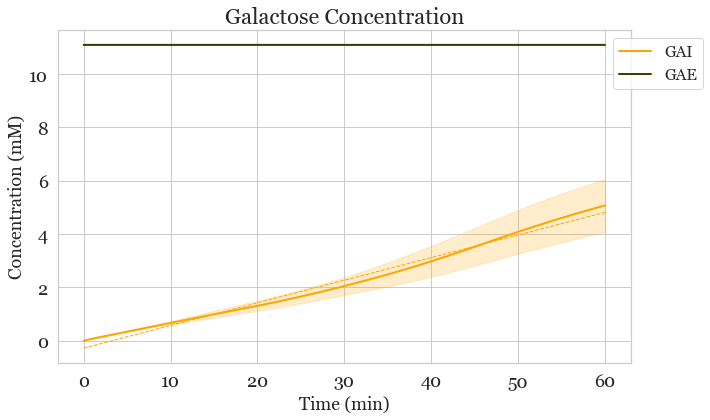

In [5]:
import seaborn as sns

# Set Seaborn style for enhanced visuals
sns.set_theme(style="whitegrid", font="Georgia", rc={"axes.labelsize": 18, "axes.titlesize": 22})

# Create the plot with Seaborn-enhanced aesthetics
fig, ax = plt.subplots(figsize=(10, 6))

# Function to plot on a specific axis
def plot_species_with_seaborn(species_list, ax):
    for species in species_list:
        if species == 'GAI' or species == 'GAE':
            time_identifier = 'odeTs'
        else:
            time_identifier = 'rdmeTs'
        time_traj = time_points[time_identifier]
        if len(all_trajectories[species]) > 0:
            color = color_map[species]
            valid_trajectories = [traj for traj in all_trajectories[species] 
                                  if len(traj) == len(time_traj)]
            
            if valid_trajectories:
                trajectories = np.stack(valid_trajectories)
                mean_traj = np.mean(trajectories, axis=0)
                std_traj = np.std(trajectories, axis=0)
                
                # Plot mean line
                sns.lineplot(x=time_traj, y=mean_traj, label=species, 
                             ax=ax, color=color, linewidth=2)
                
                # Add shaded area for standard deviation
                ax.fill_between(time_traj, 
                                mean_traj - std_traj,
                                mean_traj + std_traj,
                                color=color, alpha=0.2)
                
                # Calculate and plot trend line
                if len(time_traj) > 1:
                    slope, intercept, _, _, _ = linregress(time_traj, mean_traj)
                    trend_line = intercept + slope * np.array(time_traj)
                    ax.plot(time_traj, trend_line, linestyle='--', 
                            color=color, linewidth=1)

# Plot all species in one graph
plot_species_with_seaborn(species_to_plot_1, ax)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Concentration (mM)')
ax.set_title('Galactose Concentration')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.14, 1),fontsize=16)

# Adjust layout
plt.tight_layout()
plt.savefig(fig_dir + 'galactose_seaborn.png', dpi=600)
plt.show()


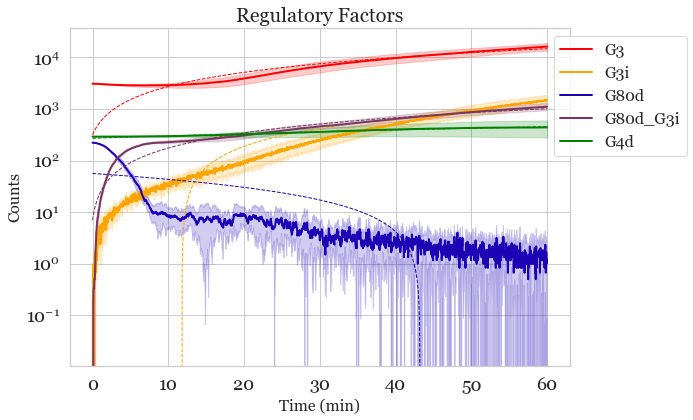

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.rcParams['font.family'] = 'Georgia'

plot_species_with_seaborn(species_to_plot_2, ax)
ax.set_xlabel('Time (min)', fontsize=16, fontfamily='Georgia')
ax.set_ylabel('Counts', fontsize=16, fontfamily='Georgia')
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Regulatory Factors', fontsize=20, fontfamily='Georgia')

ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=16)

# Adjust layout
plt.tight_layout()
plt.savefig(fig_dir+'regulatory_factor.png', dpi=600)
plt.show()

## Region specific graphs

In [7]:
print(region_traj['regions'])

['extracellular', 'obstructions', 'plasmaMembrane', 'cytoplasm', 'nucleoplasm', 'ribosomes']


plot the thrid graph G2 coutns by region

In [54]:
def plot_species_by_region_diy(interested_species, interested_regions, traj_file, fig_dir, regionTs, regionYs, dpi=300, if_log_traj=False,if_log_heat=False):
    '''
    Plot a heatmap-style trajectory with fluctuation bands for multiple species trajectories across different regions.
    Heatmap values can be displayed in log scale if `if_log=True`.
    
    Parameters:
        interested_species (str): Name of the species to plot
        interested_regions (list): List of regions of interest
        traj_file (str): Name of the trajectory file (for title)
        fig_dir (str): Directory to save the figure
        regionTs (array): Time points
        regionYs (dict): Dictionary containing species trajectories for multiple trajectories
                         Format: {species_name: [[traj1], [traj2], ...], species_name2: [...], ...}
        dpi (int): Resolution for saving the plot
        if_log (bool): Whether to display the heatmap in log scale
    '''
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    # Create figure with transparent background
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                                   gridspec_kw={'height_ratios': [3, 1]},
                                   facecolor='none')
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    
    # Get data for the species
    species_data = regionYs.get(interested_species, [])
    
    if not species_data:
        print(f"No data found for species: {interested_species}")
        return
    
    # Flatten and calculate statistics for trajectories
    avg_trajectories = []
    std_devs = []
    for region_trajs in zip(*species_data):  # Transpose to group by region
        avg_trajectory = np.mean(region_trajs, axis=0)  # Average across multiple trajectories
        std_dev = np.std(region_trajs, axis=0)  # Standard deviation across trajectories
        avg_trajectories.append(avg_trajectory)
        std_devs.append(std_dev)
    
    # Plot averaged trajectories with shaded fluctuation bands
    for idx, (avg_traj, std_dev) in enumerate(zip(avg_trajectories, std_devs)):
        color = sns.color_palette("husl", len(interested_regions))[idx]
        ax1.plot(regionTs, avg_traj, label=f'{interested_regions[idx]}', 
                 color=color, alpha=0.8)
        ax1.fill_between(regionTs, avg_traj - std_dev, avg_traj + std_dev, 
                         color=color, alpha=0.3)
    
    ax1.set_xlabel('Time (min)', fontsize=20, fontfamily='Georgia')
    ax1.set_ylabel('Count', fontsize=20, fontfamily='Georgia')
    if if_log_traj:
        ax1.set_yscale('log')
    ax1.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=16)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=18)
    ax1.set_title(str(interested_species + ' Region Distribution'), fontsize=20, fontfamily='Georgia')
    # Create heatmap data for averaged trajectories
    heatmap_data = np.array(avg_trajectories)
    
    # Apply logarithmic transformation if requested
    if if_log_heat:
        heatmap_data = np.log10(heatmap_data + 1e-6)  # Add a small constant to avoid log(0)
    
    # Plot heatmap
    im = ax2.imshow(heatmap_data, 
                    aspect='auto', 
                    extent=[regionTs[0], regionTs[-1], -0.5, len(interested_regions)-0.5],
                    cmap='magma',  # or 'inferno', 'plasma', 'RdYlBu_r', 'coolwarm'
                    interpolation='nearest')
    
    # Customize heatmap
    ax2.set_yticks(range(len(interested_regions)))
    ax2.set_yticklabels(interested_regions)
    ax2.set_xlabel('Time (min)', fontsize=20, fontfamily='Georgia')
    ax2.set_ylabel('Regions', fontsize=20, fontfamily='Georgia')
    ax2.tick_params(axis='both', which='major', labelsize=18)
    ax2.set_title(str(interested_species + ' Region Distribution'), fontsize=20, fontfamily='Georgia')
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Log(Count)' if if_log_heat else 'Count', rotation=270, labelpad=15)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure with transparency
    plt.savefig(f"{fig_dir}{traj_file}_{interested_species}_region_distribution.png", 
                dpi=dpi, 
                bbox_inches='tight',
                transparent=True,
                facecolor='none',
                edgecolor='none')
    plt.show()
    plt.close()


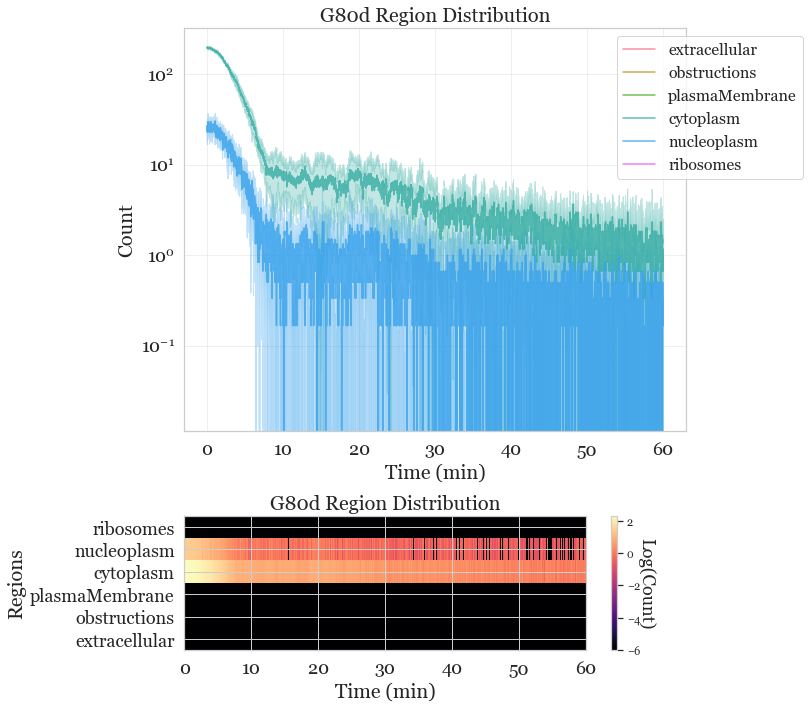

In [55]:
interested_species = 'G80d'
interested_regions = region_traj['regions']
plot_species_by_region_diy(interested_species, interested_regions, traj_file, fig_dir, time_points['regionTs'], all_region_trajectories,dpi=600,if_log_traj=True,if_log_heat=True)

plot the fourth graph G80d coutns by region

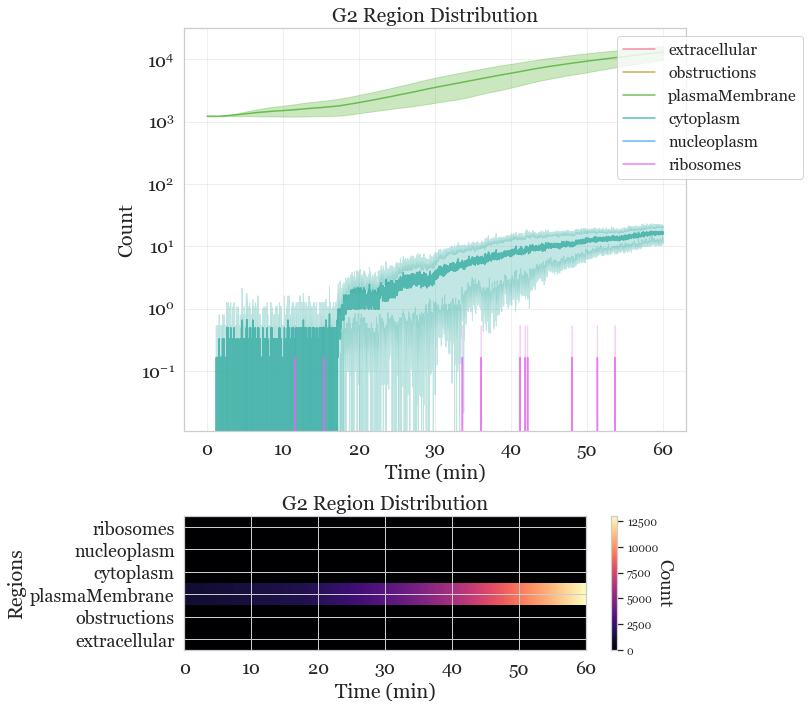

In [56]:
interested_species = 'G2'
interested_regions = region_traj['regions']
plot_species_by_region_diy(interested_species, interested_regions, traj_file, fig_dir, time_points['regionTs'], all_region_trajectories,dpi=600,if_log_traj=True,if_log_heat=False)